In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

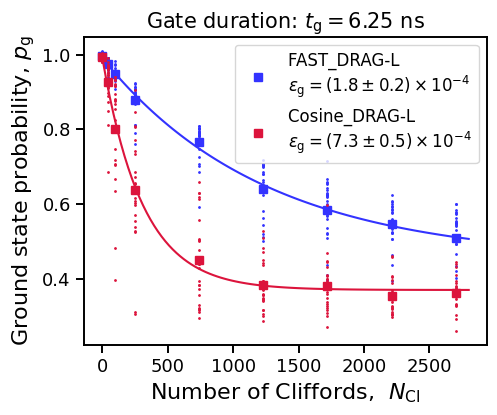

In [2]:
#Re-read csv-files and plot
pulse_names = ['FAST_DRAG-L', 'Cosine_DRAG-L']
dark_blue = [51/255,51/255,255/255] #[65,105,225]/255; %royal blue
crimson = [220/255, 20/255, 60/255] 

colors_dict = {'FAST_DRAG-L': dark_blue, 
               'Cosine_DRAG-L': crimson,
    }


fig, ax = plt.subplots(1, 1, figsize=(5.2,4))
for pulse in pulse_names:
    #Experiments
    pg_vs_N_cliffords_and_idx_mat = np.genfromtxt('%s/pg_vs_N_cliffords_and_idx_mat.csv'%(pulse), delimiter=',')
    pg_ave_vs_N_cliffords_arr = np.mean(pg_vs_N_cliffords_and_idx_mat, axis=0)
    N_cliffords_arr = np.genfromtxt('%s/N_cliffords_arr.csv'%(pulse), delimiter=',')
    #Fit
    pg_fit_vs_N_cliffords = np.genfromtxt('%s/pg_fit_vs_N_cliffords.csv'%(pulse), delimiter=',')
    N_cliffords_arr_for_fit = np.genfromtxt('%s/N_cliffords_arr_for_fit.csv'%(pulse), delimiter=',')
    #Gate error and uncertainty extracted from the fit
    gate_error_and_uncertainty = np.genfromtxt('%s/error_per_gate_and_uncertainty.csv'%(pulse), delimiter=',')


    plt.plot(N_cliffords_arr, np.transpose(pg_vs_N_cliffords_and_idx_mat),  '.', color=colors_dict[pulse], markersize=2)
    plt.plot(N_cliffords_arr, pg_ave_vs_N_cliffords_arr,  's', color=colors_dict[pulse], 
             label = '%s \n'%(pulse) + r'$\varepsilon_\mathrm{g} = (%.1f \pm %.1f) \times 10^{-4}$'%(gate_error_and_uncertainty[0]*1e4,gate_error_and_uncertainty[1]*1e4 ))
    plt.plot(N_cliffords_arr_for_fit, pg_fit_vs_N_cliffords,  '-', color=colors_dict[pulse])
    
plt.xlabel(r'Number of Cliffords,  $N_\mathrm{Cl}$', fontsize = 16)
plt.ylabel(r'Ground state probability, $p_\mathrm{g}$', fontsize = 16)
plt.legend(fontsize = 12, loc = 'upper right') #'upper right')
plt.title('Gate duration: $t_\mathrm{g} = 6.25$ ns', fontsize=15)
ax.tick_params(length=6, width = 1.4, labelsize=13)
ax.tick_params(length=6, width = 1.4)
for side in ['top', 'left', 'right', 'bottom']:
    ax.spines[side].set_linewidth(1.4)
